# Agriculture Data Analysis & Crop Yield Insights

This notebook analyzes agricultural data to understand key factors affecting crop yield. It includes data preprocessing, exploratory data analysis (EDA), and visualizations.

# Importing Required Libraries

We import necessary Python libraries for data manipulation and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading and Inspecting the Data

In [2]:
# Load Dataset
df = pd.read_csv('Agriculture_data.csv')
print("Data Preview:")
print(df.head())

# Shape of dataset
print("Shape of dataset:", df.shape)

# Remove missing values & Data preprocessing
df.dropna(inplace=True)  

Data Preview:
   Crop_Type  Soil_pH  Rainfall  Temperature  Fertilizer_Use  Yield  \
0  Sugarcane      7.4       376           39              70   2.07   
1       Oats      5.1      1937           21              82   3.45   
2     Cotton      4.5      1569           39              51   4.94   
3       Oats      6.6       938           23              43   5.74   
4       Oats      4.8      1881           37             113   3.63   

   Water_Efficiency Soil_pH_Category Rainfall_Category Water_Usage_Estimate  \
0          0.005505          Neutral               Low                  Low   
1          0.001781           Acidic              High                 High   
2          0.003149           Acidic              High                 High   
3          0.006119          Neutral            Medium               Medium   
4          0.001930           Acidic              High                 High   

  Irrigation  Year  
0      Flood  1980  
1  Sprinkler  1980  
2       Drip  1980  


In [3]:
# Statistical Summary
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
          Soil_pH     Rainfall  Temperature  Fertilizer_Use       Yield  \
count  500.000000   500.000000   500.000000      500.000000  500.000000   
mean     6.314800  1143.540000    27.088000       75.414000    4.092000   
std      0.998988   485.795342     7.457848       26.377531    1.140373   
min      4.500000   303.000000    15.000000       30.000000    2.020000   
25%      5.475000   721.000000    21.000000       52.000000    3.175000   
50%      6.400000  1144.000000    27.000000       76.000000    4.070000   
75%      7.200000  1544.000000    33.000000       96.000000    5.120000   
max      8.000000  2000.000000    40.000000      120.000000    5.990000   

       Water_Efficiency         Year  
count        500.000000   500.000000  
mean           0.004558  2000.764000  
std            0.003026    12.737377  
min            0.001148  1980.000000  
25%            0.002561  1990.000000  
50%            0.003598  2000.000000  
75%            0.005622  2011.

# Exploratory Data Analysis (EDA)

Analyzing statistical summaries, distributions, and relationships between variables.

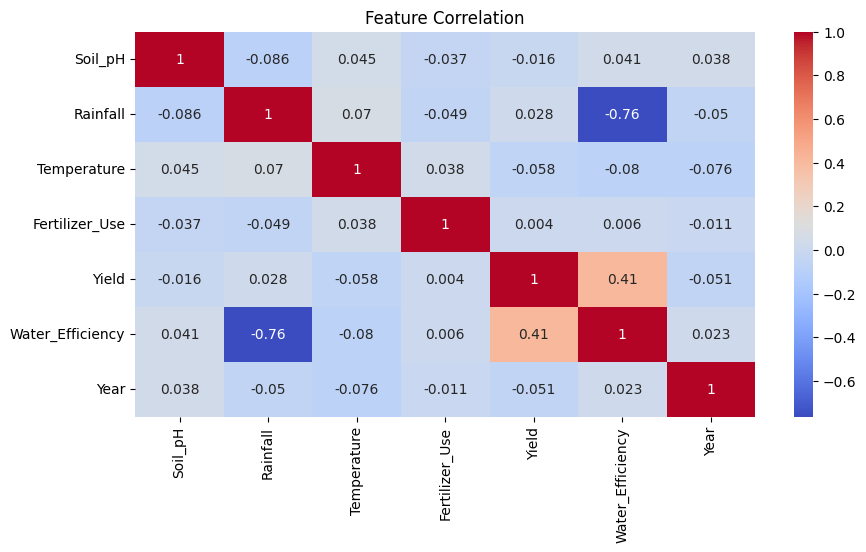

In [4]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(10, 5))
numerical_df = df.select_dtypes(include=['number'])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Data Visualization

Using various plots to understand trends and patterns in the dataset.

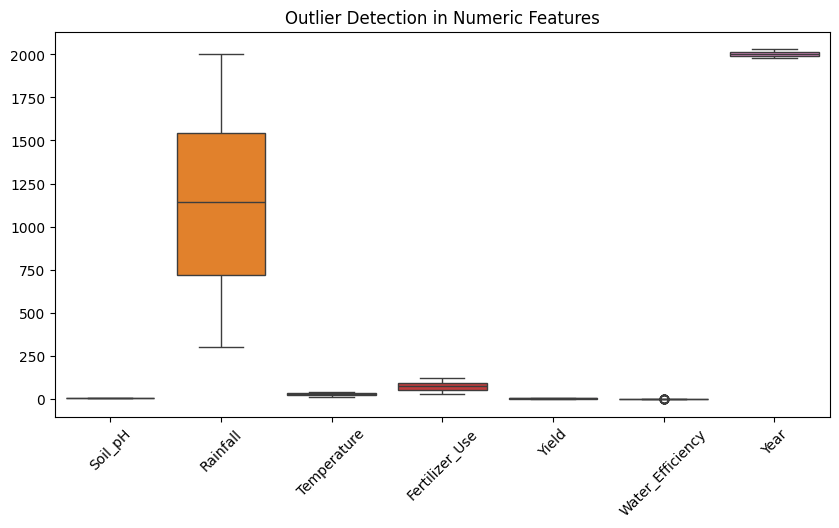

In [5]:
# Outlier Detection
plt.figure(figsize=(10,5))
sns.boxplot(data=numerical_df)
plt.title("Outlier Detection in Numeric Features")
plt.xticks(rotation=45)
plt.show()

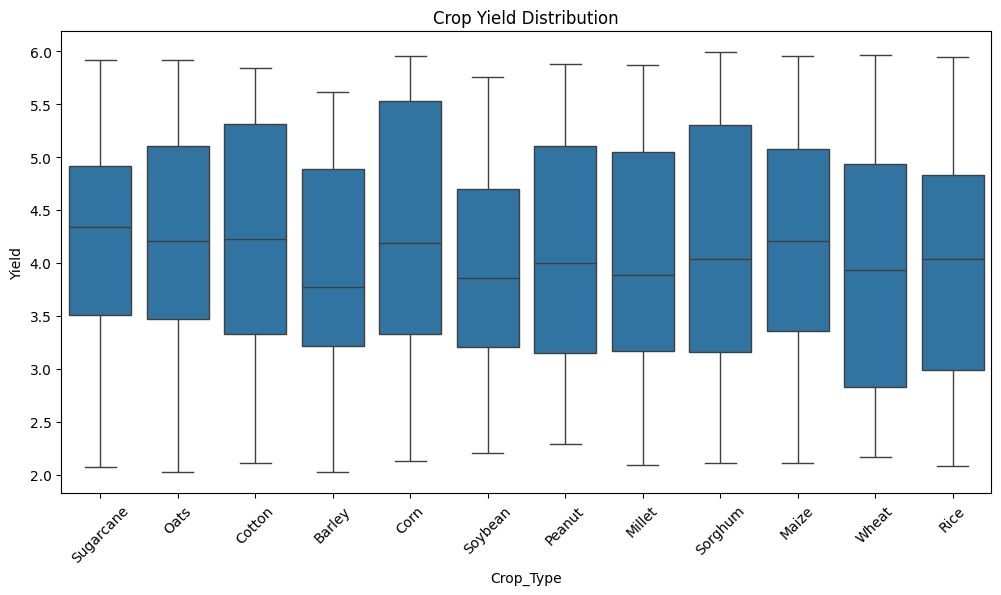

In [6]:
# Crop Yield Analysis
plt.figure(figsize=(12, 6))
sns.boxplot(x='Crop_Type', y='Yield', data=df)
plt.title("Crop Yield Distribution")
plt.xticks(rotation=45)
plt.show()

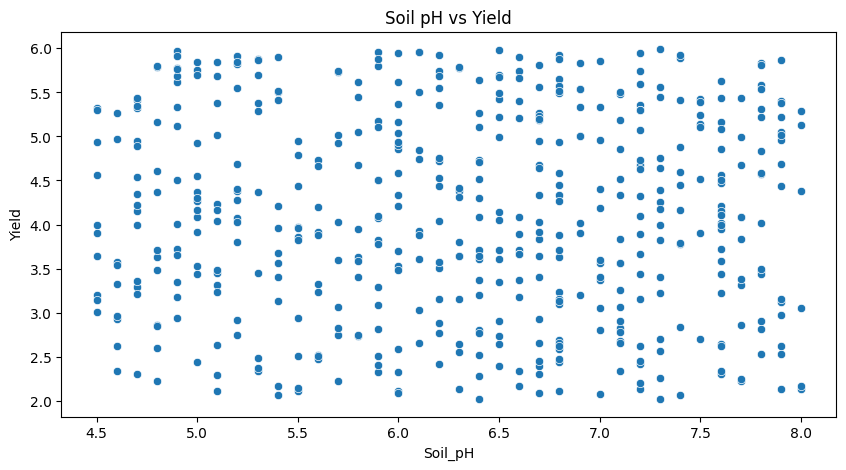

In [7]:
# Soil Quality vs Yield
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Soil_pH', y='Yield', data=df)
plt.title("Soil pH vs Yield")
plt.show()

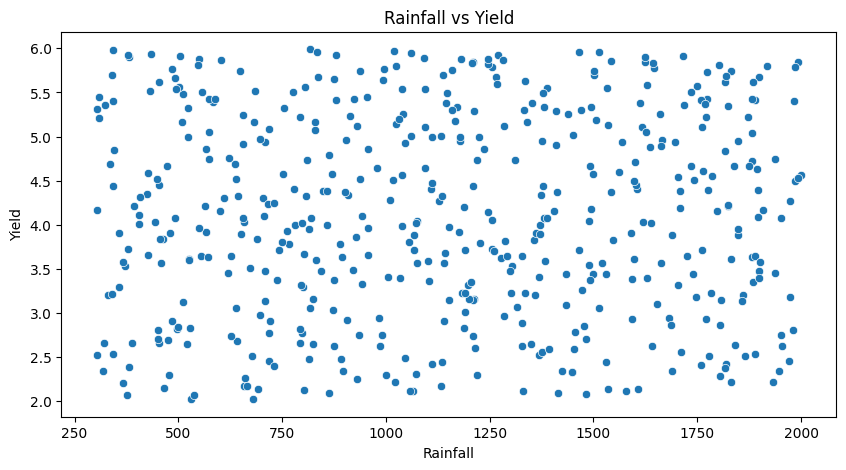

In [8]:
# Rainfall vs Yield
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Rainfall', y='Yield', data=df)
plt.title("Rainfall vs Yield")
plt.show()

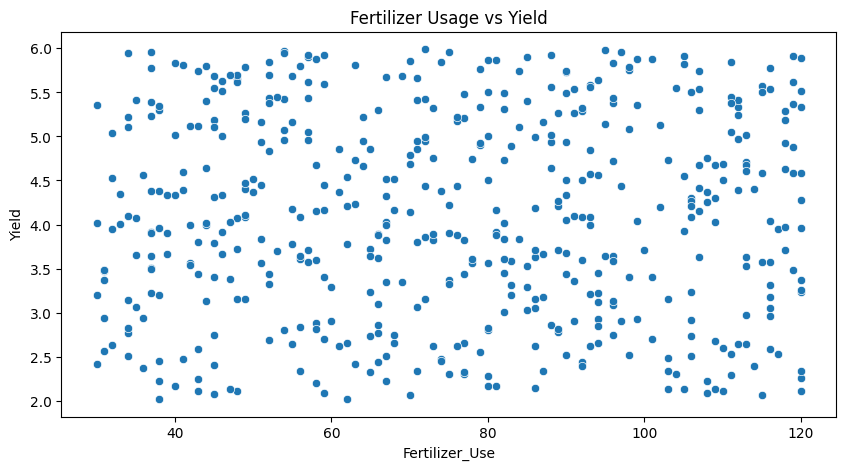

In [9]:
# Fertilizer Usage vs Yield
plt.figure(figsize=(10,5))
sns.scatterplot(x='Fertilizer_Use', y='Yield', data=df)
plt.title("Fertilizer Usage vs Yield")
plt.show()

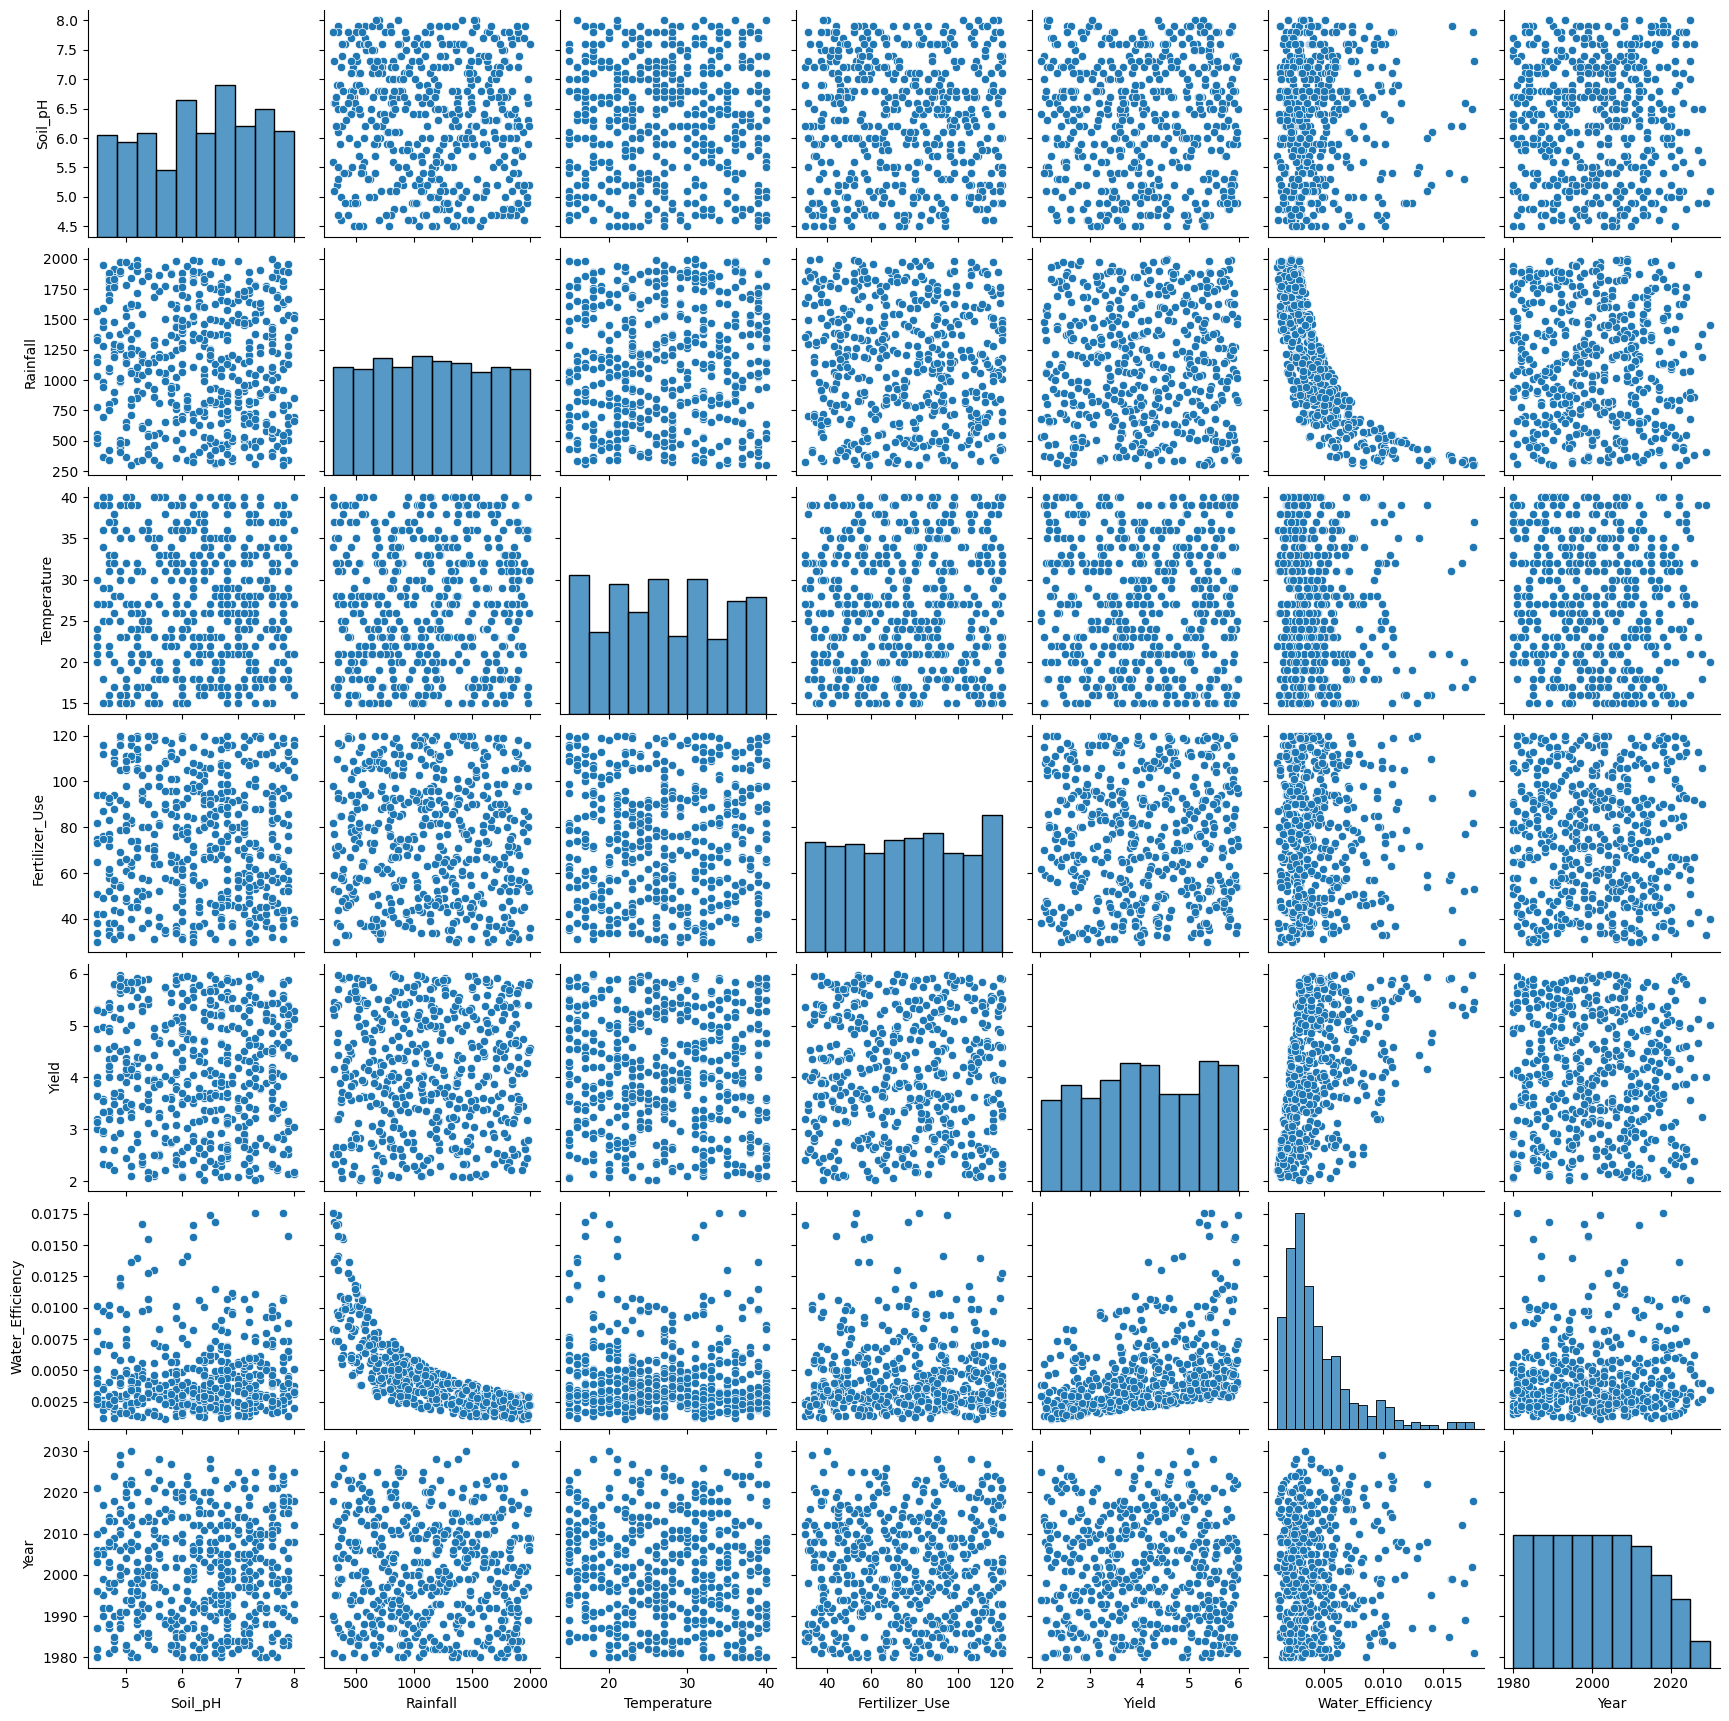

In [10]:
# Pair Plot for Feature Relationships
sns.pairplot(numerical_df)
plt.show()

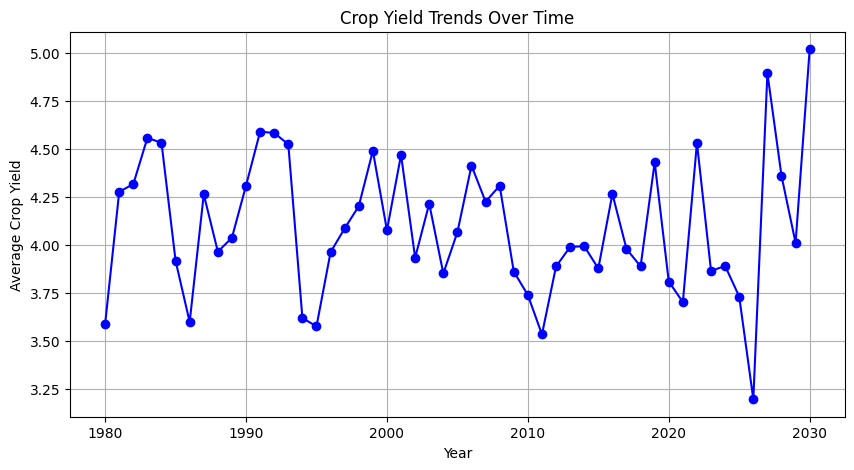

In [11]:
# Line Plot (Trend Over Time)
# calculate the average yield per year and plot crop yield changes over the years.

df_yearly = df.groupby('Year', as_index=False)['Yield'].mean()
plt.figure(figsize=(10, 5))
plt.plot(df_yearly['Year'], df_yearly['Yield'], marker='o', linestyle='-', color='b')
plt.xlabel('Year')
plt.ylabel('Average Crop Yield')
plt.title('Crop Yield Trends Over Time')
plt.grid(True)
plt.show()

C:\Users\Bhushan Patange\AppData\Local\Temp\ipykernel_191092\1858250899.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=df['Crop_Type'], y=df['Yield'], estimator=np.mean, ci=None)


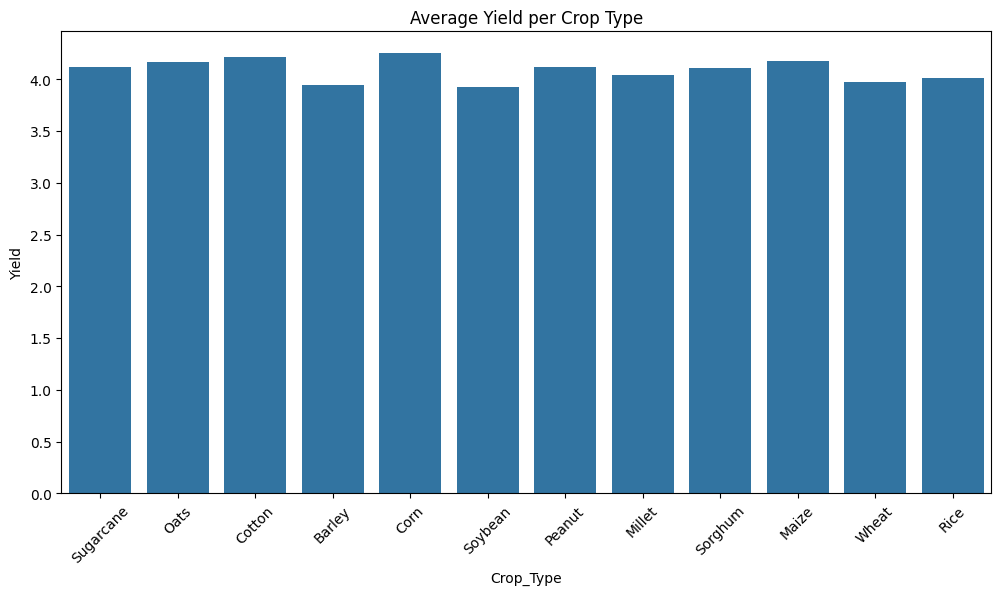

In [12]:
# Bar Plot for Average Yield Per Crop
plt.figure(figsize=(12,6))
sns.barplot(x=df['Crop_Type'], y=df['Yield'], estimator=np.mean, ci=None)
plt.xticks(rotation=45)
plt.title("Average Yield per Crop Type")
plt.show()

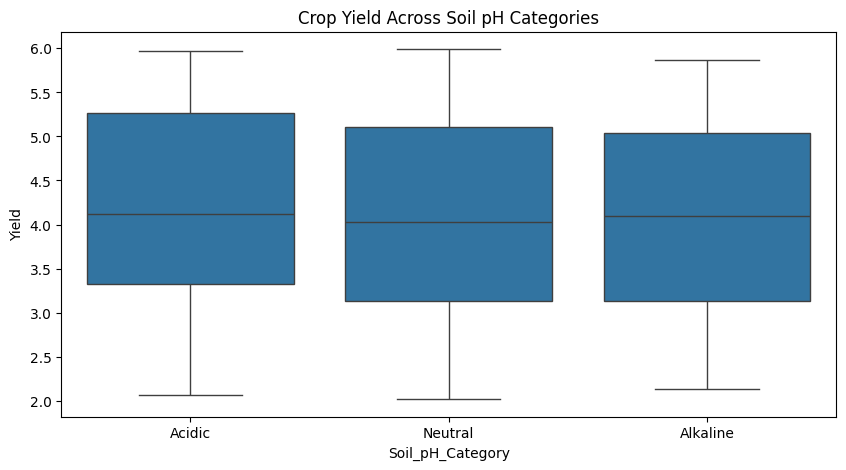

In [13]:
# Soil pH Category Analysis
df['Soil_pH_Category'] = pd.cut(df['Soil_pH'], bins=[0, 5.5, 7.5, 14], labels=['Acidic', 'Neutral', 'Alkaline'])
plt.figure(figsize=(10,5))
sns.boxplot(x='Soil_pH_Category', y='Yield', data=df)
plt.title("Crop Yield Across Soil pH Categories")
plt.show()

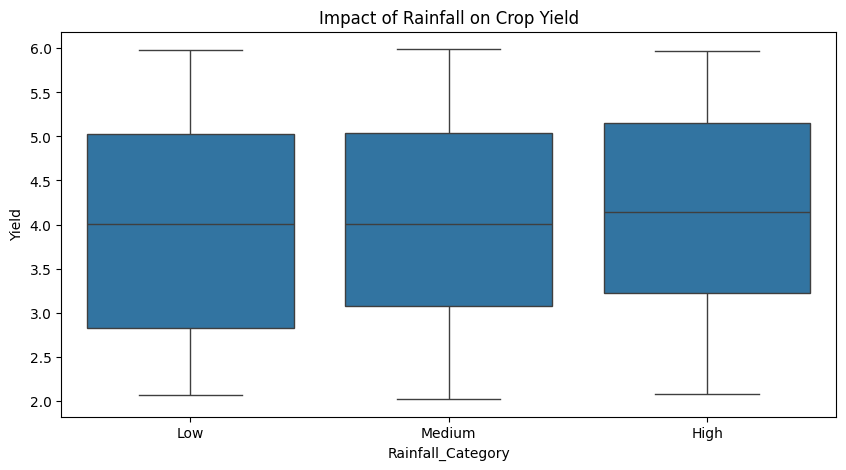

In [14]:
# Rainfall Categories and Yield
df['Rainfall_Category'] = pd.cut(df['Rainfall'], bins=[0, 500, 1000, 2000], labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(10,5))
sns.boxplot(x='Rainfall_Category', y='Yield', data=df)
plt.title("Impact of Rainfall on Crop Yield")
plt.show()

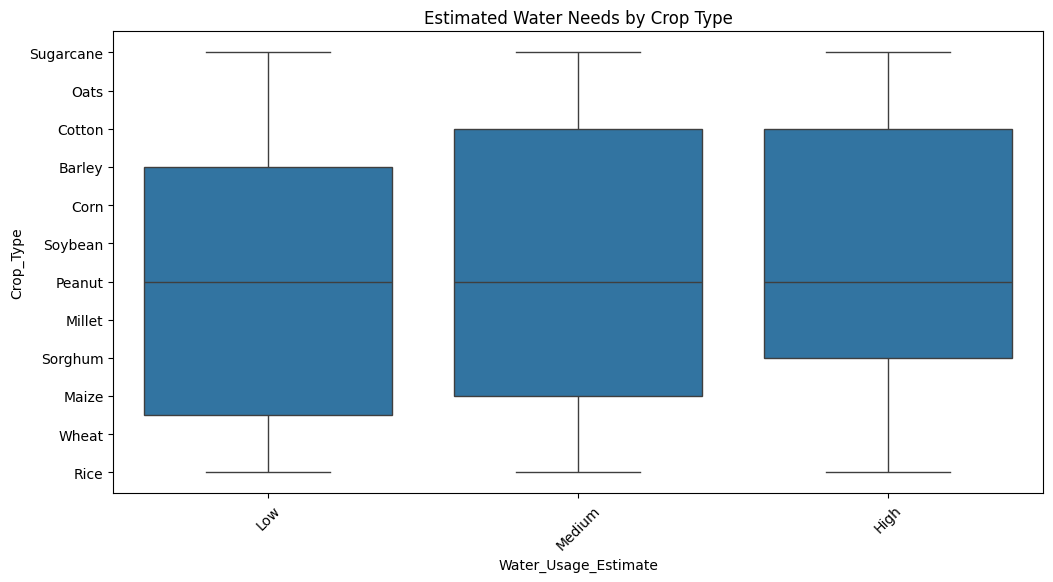

In [15]:
# Water Usage Estimate Based on Rainfall
df['Water_Usage_Estimate'] = pd.cut(df['Rainfall'], bins=[0, 500, 1000, 2000], labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(12,6))
sns.boxplot(x='Water_Usage_Estimate', y='Crop_Type', data=df)
plt.xticks(rotation=45)
plt.title("Estimated Water Needs by Crop Type")
plt.show()

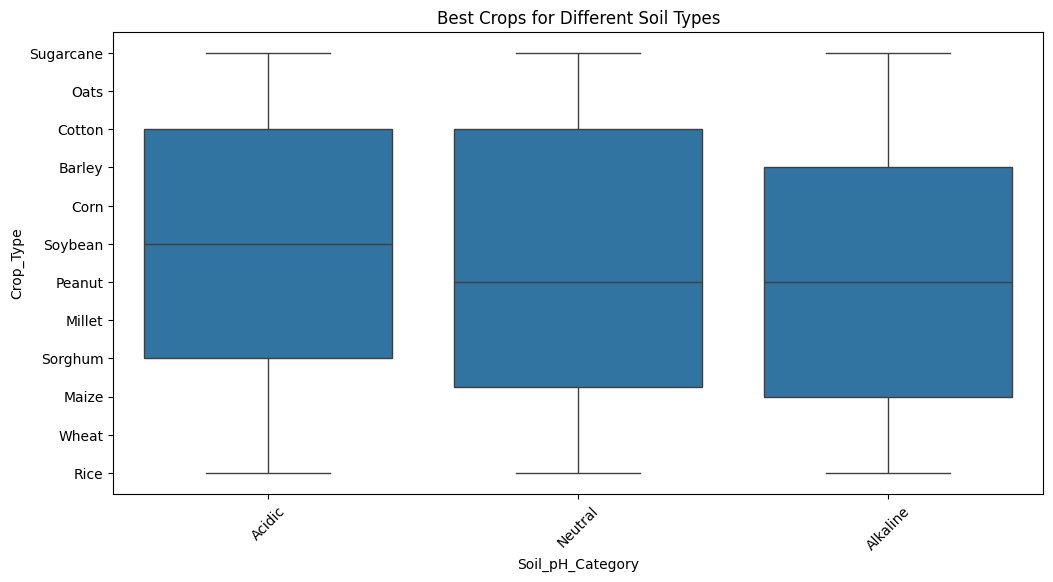

In [16]:
# Best Crop for Different Soil Types
plt.figure(figsize=(12,6))
sns.boxplot(x='Soil_pH_Category', y='Crop_Type', data=df)
plt.xticks(rotation=45)
plt.title("Best Crops for Different Soil Types")
plt.show()

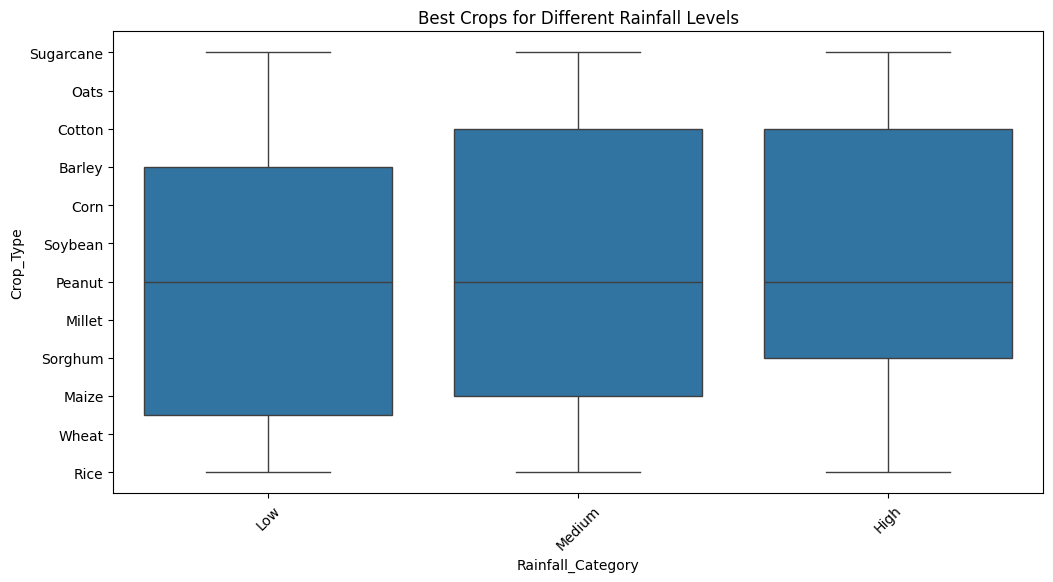

In [17]:
# Best Crop Type for Different Rainfall Levels
plt.figure(figsize=(12,6))
sns.boxplot(x='Rainfall_Category', y='Crop_Type', data=df)
plt.xticks(rotation=45)
plt.title("Best Crops for Different Rainfall Levels")
plt.show()

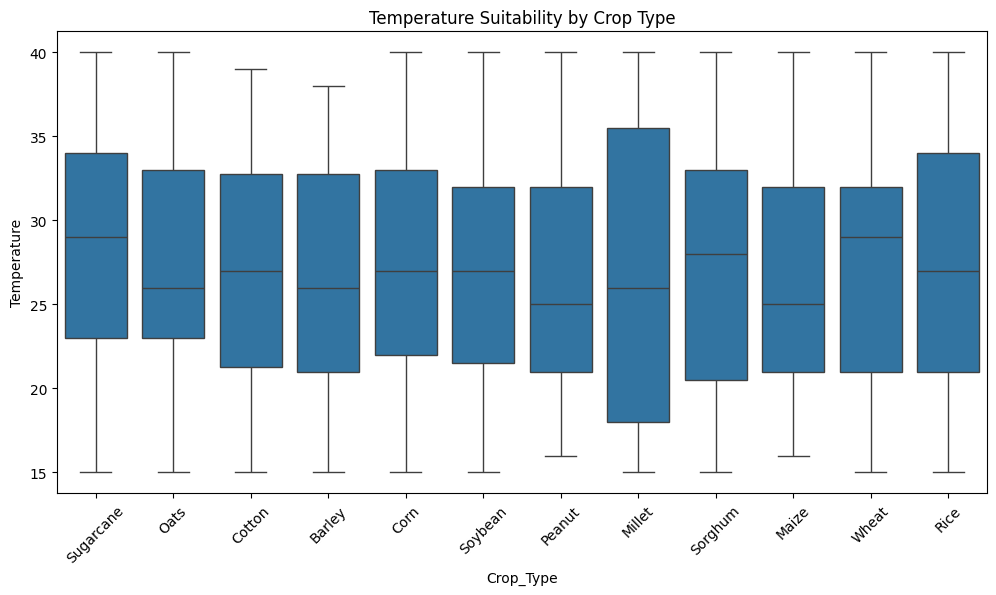

In [18]:
if 'Temperature' in df.columns:
    plt.figure(figsize=(12,6))
    sns.boxplot(x='Crop_Type', y='Temperature', data=df)
    plt.xticks(rotation=45)
    plt.title("Temperature Suitability by Crop Type")
    plt.show()

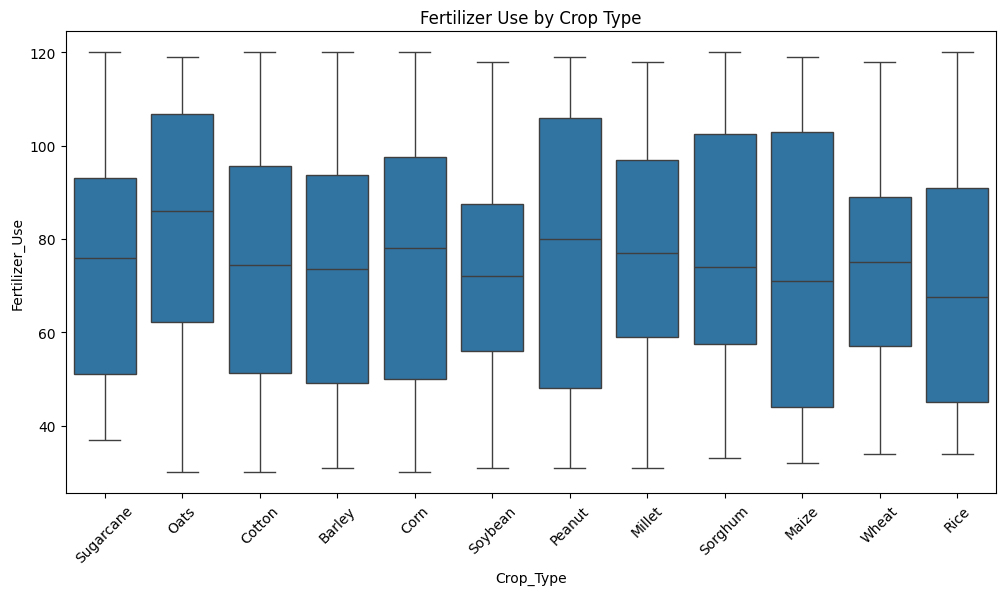

In [19]:
# Fertilizer Use by Crop Type
plt.figure(figsize=(12,6))
sns.boxplot(x='Crop_Type', y='Fertilizer_Use', data=df)
plt.xticks(rotation=45)
plt.title("Fertilizer Use by Crop Type")
plt.show()

In [20]:
# Seasonal Yield Analysis (Requires Date Column)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month
    plt.figure(figsize=(12,6))
    sns.lineplot(x='Month', y='Yield', data=df, ci=None)
    plt.title("Average Crop Yield by Month")
    plt.xlabel("Month")
    plt.ylabel("Yield")
    plt.show()

C:\Users\Bhushan Patange\AppData\Local\Temp\ipykernel_191092\4178939658.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Year', y='Yield', data=df, ci=None)


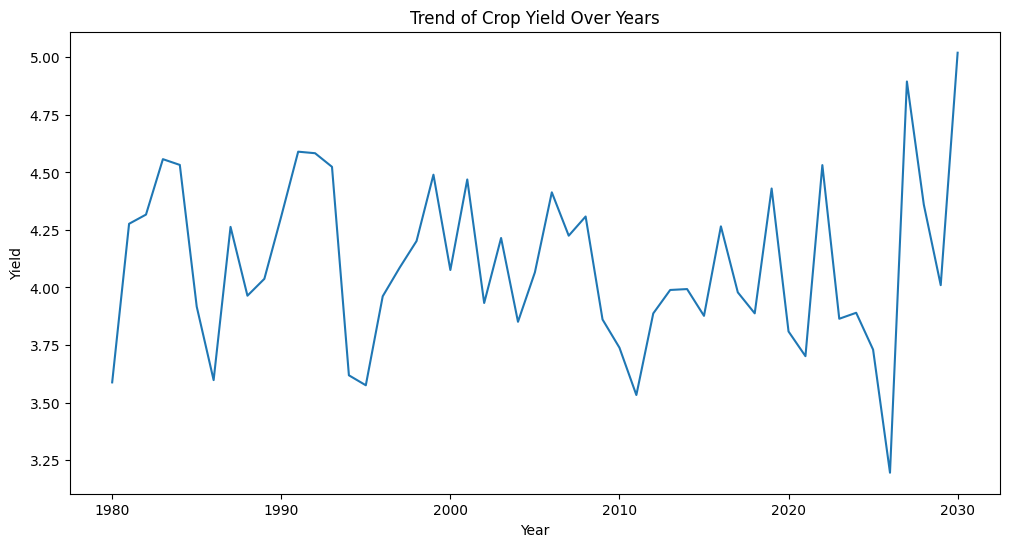

In [21]:
# Yield Trend Over Years
if 'Year' in df.columns:
    plt.figure(figsize=(12,6))
    sns.lineplot(x='Year', y='Yield', data=df, ci=None)
    plt.title("Trend of Crop Yield Over Years")
    plt.xlabel("Year")
    plt.ylabel("Yield")
    plt.show()

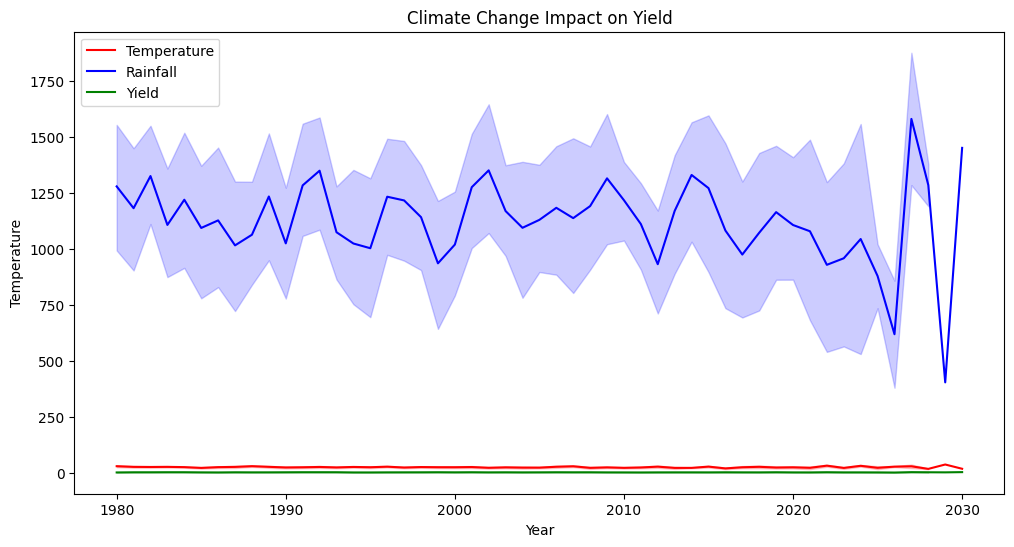

In [22]:
# Climate Change Impact on Yield
if {'Year', 'Temperature', 'Rainfall'}.issubset(df.columns):
    plt.figure(figsize=(12,6))
    sns.lineplot(x='Year', y='Temperature', data=df, label='Temperature', color='red')
    sns.lineplot(x='Year', y='Rainfall', data=df, label='Rainfall', color='blue')
    sns.lineplot(x='Year', y='Yield', data=df, label='Yield', color='green')
    plt.title("Climate Change Impact on Yield")
    plt.legend()
    plt.show()

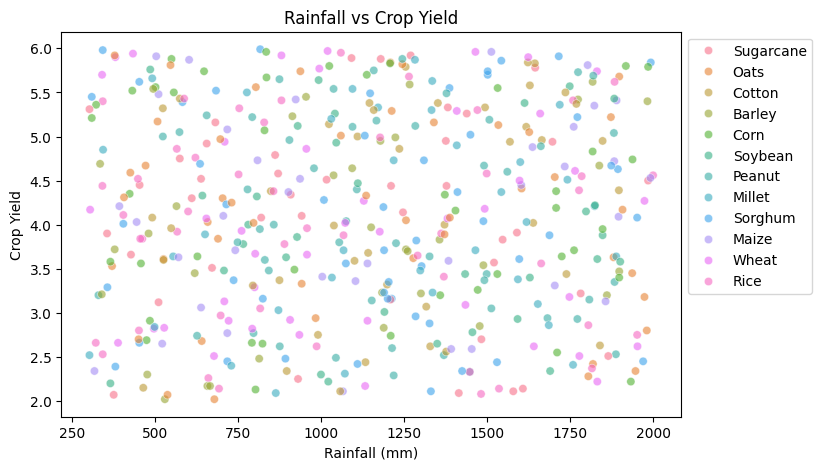

In [23]:
# Scatter Plot (Relationship Between Variables)
# Use this to check correlation between two numerical factors, e.g., rainfall vs. yield.

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Rainfall'], y=df['Yield'], hue=df['Crop_Type'], alpha=0.6)
plt.xlabel('Rainfall (mm)')
plt.ylabel('Crop Yield')
plt.title('Rainfall vs Crop Yield')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside for better visibility
plt.show()



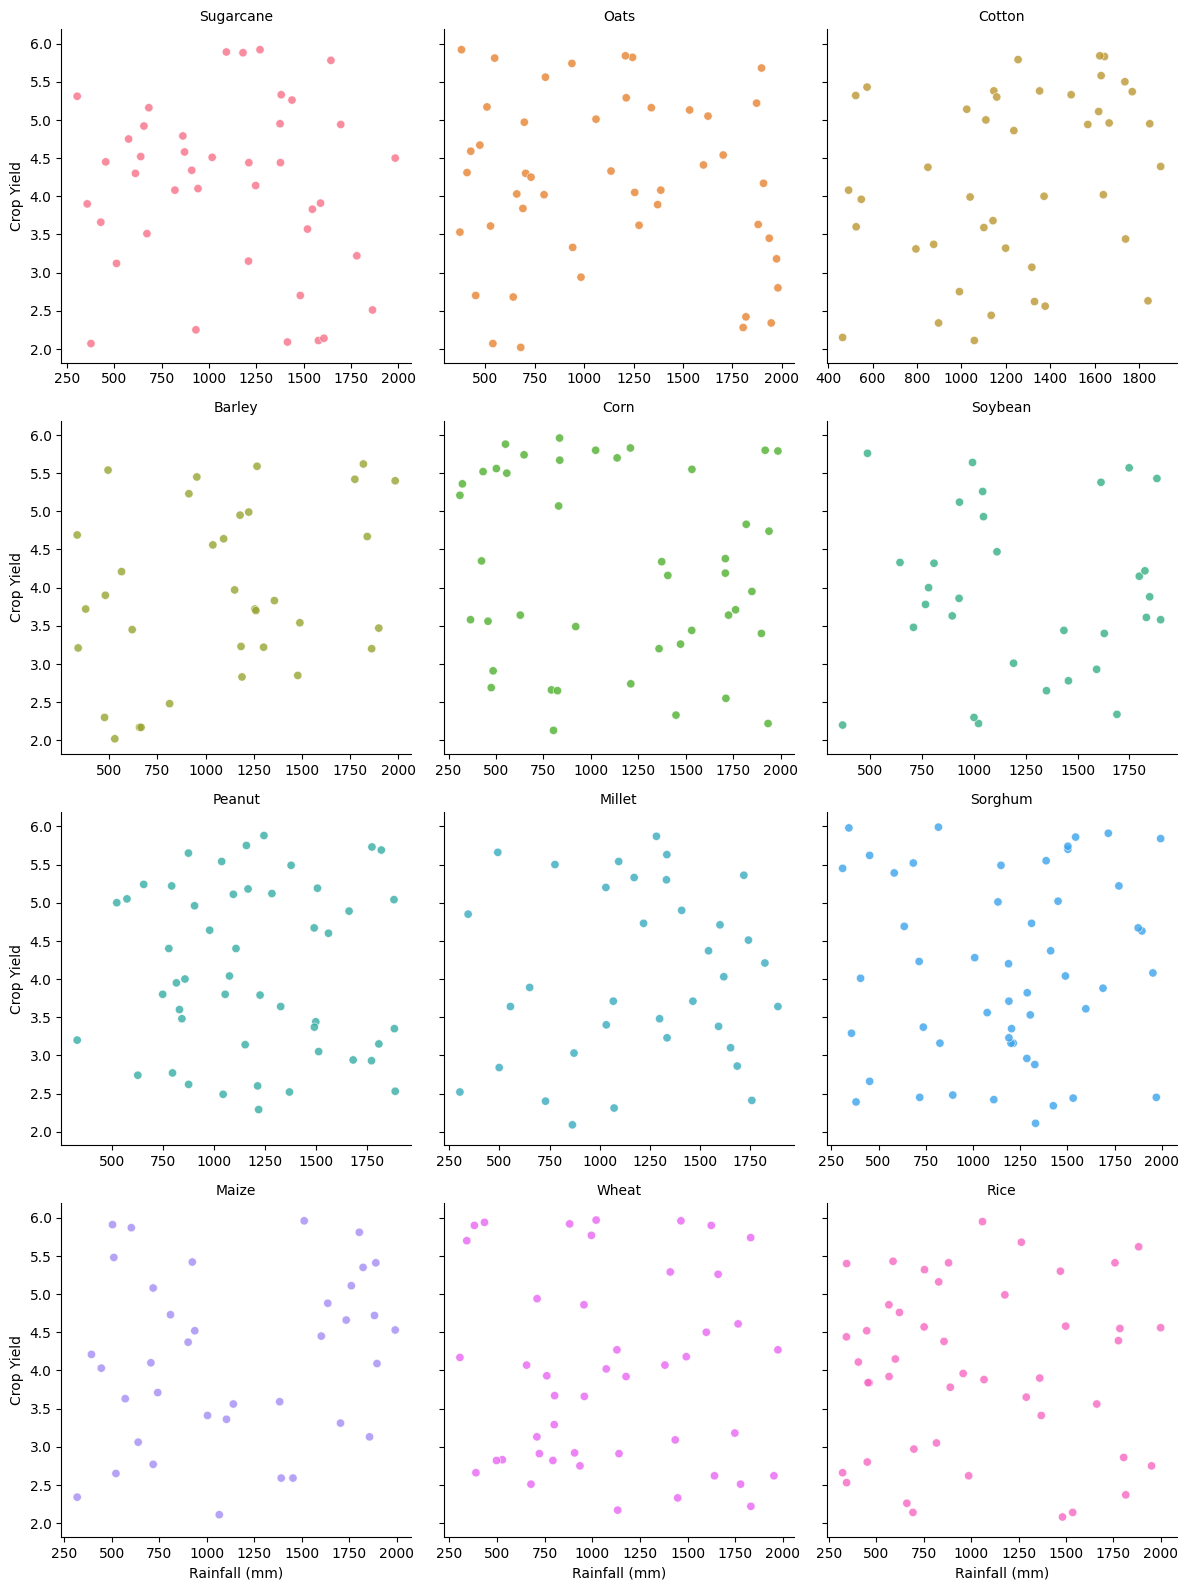

In [24]:
# Scatter Plot (Relationship Between Variables)
# Separate Scatter Plots for Each Crop Type
# Instead of combining all crops in one plot, create a grid of scatter plots, one for each crop.

# Create a color palette for different crops
unique_crops = df["Crop_Type"].unique()
palette = dict(zip(unique_crops, sns.color_palette("husl", len(unique_crops))))

# Generate facet grid with different colors for each crop
g = sns.FacetGrid(df, col="Crop_Type", col_wrap=3, height=4, sharex=False, sharey=True)
g.map_dataframe(sns.scatterplot, x="Rainfall", y="Yield", hue="Crop_Type", palette=palette, alpha=0.8)

# Labeling
g.set_axis_labels("Rainfall (mm)", "Crop Yield")
g.set_titles("{col_name}")

plt.show()


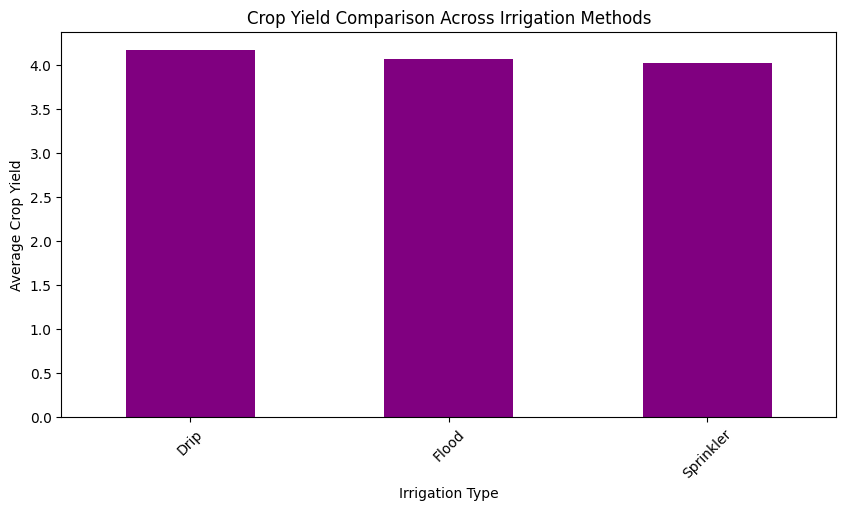

In [25]:
# Bar plot: Irrigation vs Yield
# Crop Yield Comparison Across Irrigation Methods

plt.figure(figsize=(10, 5))
df.groupby('Irrigation')['Yield'].mean().plot(kind='bar', color='purple')
plt.xlabel('Irrigation Type')
plt.ylabel('Average Crop Yield')
plt.title('Crop Yield Comparison Across Irrigation Methods')
plt.xticks(rotation=45)
plt.show()


C:\Users\Bhushan Patange\AppData\Local\Temp\ipykernel_191092\4053871957.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Rainfall_Category')['Yield'].mean().plot(kind='bar', color='blue')


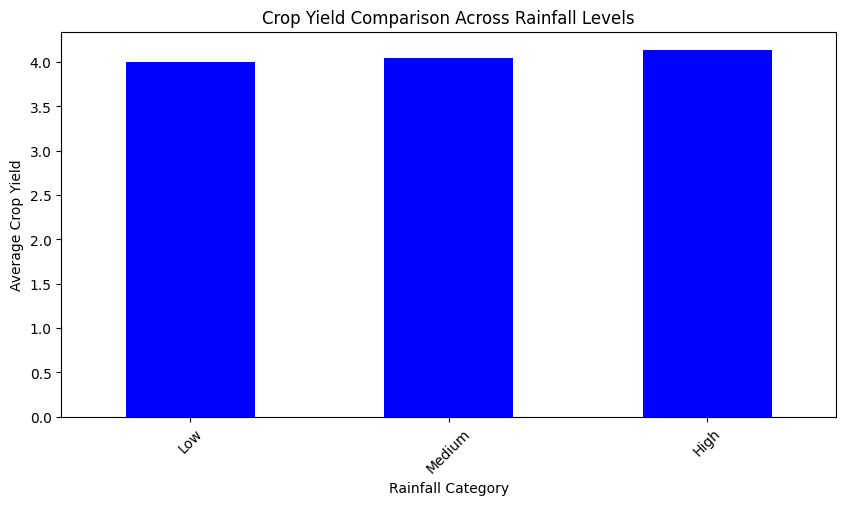

In [26]:
# Bar plot: Irrigation vs Yield
# Crop Yield Comparison Across Rainfall Category

plt.figure(figsize=(10, 5))
df.groupby('Rainfall_Category')['Yield'].mean().plot(kind='bar', color='blue')
plt.xlabel('Rainfall Category')
plt.ylabel('Average Crop Yield')
plt.title('Crop Yield Comparison Across Rainfall Levels')
plt.xticks(rotation=45)
plt.show()


In [27]:
# Best Irrigation Method for Different Crops
best_irrigation = df.groupby("Crop_Type")["Irrigation"].agg(lambda x: x.value_counts().idxmax())
print(best_irrigation)

Crop_Type
Barley       Sprinkler
Corn              Drip
Cotton            Drip
Maize             Drip
Millet       Sprinkler
Oats         Sprinkler
Peanut            Drip
Rice             Flood
Sorghum           Drip
Soybean      Sprinkler
Sugarcane        Flood
Wheat        Sprinkler
Name: Irrigation, dtype: object


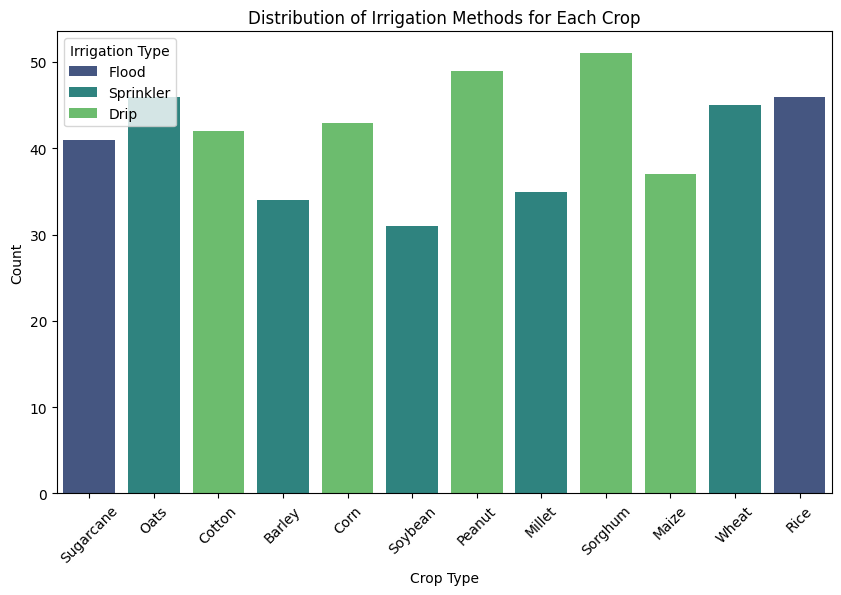

In [28]:
# Best Irrigation Method for Different Crops
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Crop_Type", hue="Irrigation", palette="viridis")
plt.title("Distribution of Irrigation Methods for Each Crop")
plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Irrigation Type")
plt.show()

In [29]:
print("Agricluture Analysis Completed!")

Agricluture Analysis Completed!
